Feb 21, 2025 - Aarjeyan Shrestha

In [ ]:
import pandas as pd
import numpy as np
import re
import string
import nltk
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.model_selection import GridSearchCV

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sthaa\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sthaa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\sthaa\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [13]:
df = pd.read_csv("dataset.csv")

In [14]:
df

,question,answer
0,What is supervised machine learning? 👶,Supervised learning is a type of machine learn...
1,What is regression? Which models can you use t...,Regression is a part of supervised ML. Regress...
2,What is linear regression? When do we use it? 👶,Linear regression is a model that assumes a li...
3,What are the main assumptions of linear regres...,There are several assumptions of linear regres...
4,What’s the normal distribution? Why do we care...,The normal distribution is a continuous probab...
...,...,...
161,Which models do you know for solving time seri...,* Simple Exponential Smoothing: approximate th...
162,"If there’s a trend in our series, how we can r...",We can explicitly model the trend (and/or seas...
163,You have a series with only one variable “y” m...,We want to look at the correlation between dif...
164,You have a series with a variable “y” and a se...,Given the assumption that the set of features ...


In [15]:
df['text'] = df['question'] + " " + df['answer']

In [16]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Lowercase
    text = text.lower()
    # Remove numeric characters
    text = re.sub(r'\d+', '', text)
    # Tokenize text
    tokens = word_tokenize(text)
    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]
    # Lemmatize tokens
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    # Remove short tokens (optional)
    tokens = [word for word in tokens if len(word) > 2]
    return tokens

df['clean_tokens'] = df['text'].apply(clean_text)


In [19]:
all_bigrams = []
for tokens in df['clean_tokens']:
    # Create bigrams from consecutive tokens
    bigrams_in_doc = list(zip(tokens, tokens[1:]))
    all_bigrams.extend(bigrams_in_doc)

bigram_freq = Counter(all_bigrams)

# Define a frequency threshold (tweak as needed)
threshold = 2

# Step 4.2: Function to merge frequent bigrams into a single token (joined by '_')
def combine_frequent_bigrams(tokens, bigram_freq, threshold=2):
    new_tokens = []
    skip_next = False
    for i in range(len(tokens) - 1):
        if skip_next:
            skip_next = False
            continue
        pair = (tokens[i], tokens[i+1])
        if bigram_freq[pair] >= threshold:
            merged = "_".join(pair)
            new_tokens.append(merged)
            skip_next = True  # Skip the next token as it is merged
        else:
            new_tokens.append(tokens[i])
    # Add the last token if it wasn't merged
    if not skip_next and tokens:
        new_tokens.append(tokens[-1])
    return new_tokens

df['clean_tokens'] = df['clean_tokens'].apply(lambda x: combine_frequent_bigrams(x, bigram_freq, threshold))


In [20]:
df.head(3)

,question,answer,text,clean_tokens
0,What is supervised machine learning? 👶,Supervised learning is a type of machine learn...,What is supervised machine learning? 👶 Supervi...,"[supervised, machine_learning, supervised_lear..."
1,What is regression? Which models can you use t...,Regression is a part of supervised ML. Regress...,What is regression? Which models can you use t...,"[regression_model, use_solve, regression_probl..."
2,What is linear regression? When do we use it? 👶,Linear regression is a model that assumes a li...,What is linear regression? When do we use it? ...,"[linear_regression, use, linear_regression, mo..."


Document Length DIstribution

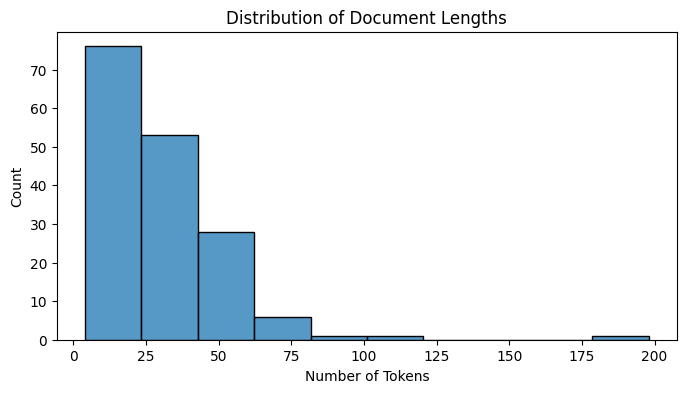

In [21]:
df['doc_length'] = df['clean_tokens'].apply(len)

plt.figure(figsize=(8,4))
sns.histplot(df['doc_length'], bins=10, kde=False)
plt.title('Distribution of Document Lengths')
plt.xlabel('Number of Tokens')
plt.ylabel('Count')
plt.show()

Most frequent tokens (including any bigrams)

Top 20 most common tokens: [('model', 48), ('\u200d⭐️', 40), ('data', 38), ('value', 38), ('feature', 28), ('problem', 25), ('word', 23), ('random_forest', 22), ('set', 21), ('need', 20), ('weight', 20), ('use', 19), ('one', 19), ('tree', 19), ('example', 17), ('mean', 17), ('error', 17), ('point', 17), ('algorithm', 16), ('used', 16)]


C:\Users\sthaa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


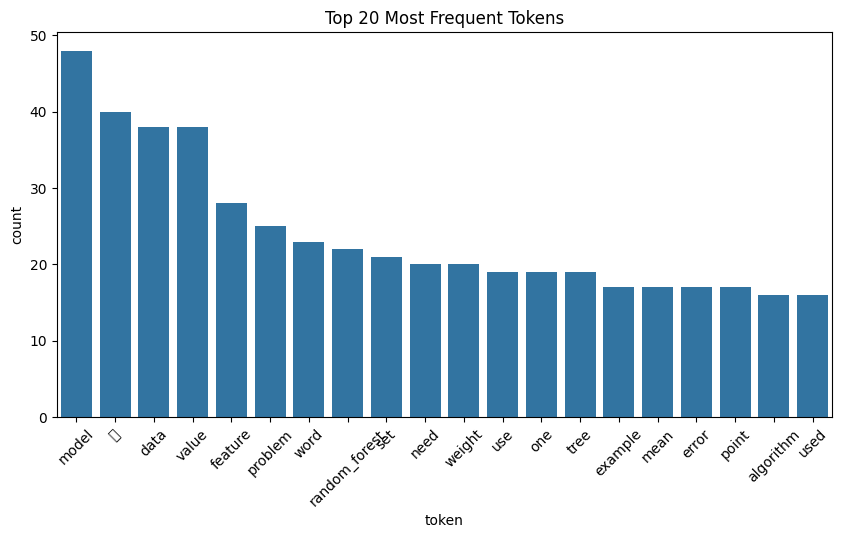

In [22]:
all_tokens = [token for tokens in df['clean_tokens'] for token in tokens]
freq_dist = nltk.FreqDist(all_tokens)
most_common = freq_dist.most_common(20)
print("Top 20 most common tokens:", most_common)

tokens_df = pd.DataFrame(most_common, columns=['token','count'])
plt.figure(figsize=(10,5))
sns.barplot(x='token', y='count', data=tokens_df)
plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Tokens")
plt.show()

In [23]:
df['clean_text'] = df['clean_tokens'].apply(lambda tokens: ' '.join(tokens))

# For LDA (using CountVectorizer)
count_vectorizer = CountVectorizer(min_df=1, max_df=0.9)
count_data = count_vectorizer.fit_transform(df['clean_text'])

# For NMF (using TfidfVectorizer)
tfidf_vectorizer = TfidfVectorizer(min_df=1, max_df=0.9)
tfidf_data = tfidf_vectorizer.fit_transform(df['clean_text'])

## LDA

In [26]:
lda = LatentDirichletAllocation(random_state=42)

# Parameter grid for n_components
param_grid = {
    'n_components': [2, 3, 4, 5, 6]  # adjust range as you see fit
}

# Using GridSearchCV to find the best number of topics
lda_search = GridSearchCV(lda, param_grid=param_grid, scoring='neg_log_loss', cv=3)
lda_search.fit(count_data)

best_lda = lda_search.best_estimator_
best_lda_topics = lda_search.best_params_['n_components']
print("Best LDA model's number of topics:", best_lda_topics)

C:\Users\sthaa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\sthaa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_validation.py", line 947, in _score
    scores = scorer(estimator, X_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: _BaseScorer.__call__() missing 1 required positional argument: 'y_true'

  warnings.warn(
C:\Users\sthaa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_search.py:1107: UserWarning: One or more of the test scores are non-finite: [nan

Best LDA model's number of topics: 2


In [27]:
def display_topics(model, feature_names, no_top_words=10):
    for idx, topic in enumerate(model.components_):
        print(f"\nTopic {idx}:")
        # argsort() returns indices sorted from smallest to largest
        # so we take the last no_top_words entries as top words
        top_indices = topic.argsort()[-no_top_words:]
        top_words = [feature_names[i] for i in top_indices]
        print(" ".join(top_words))

count_feature_names = count_vectorizer.get_feature_names_out()
display_topics(best_lda, count_feature_names, no_top_words=7)


Topic 0:
feature point user use regression value word

Topic 1:
feature problem regularization random_forest value data model


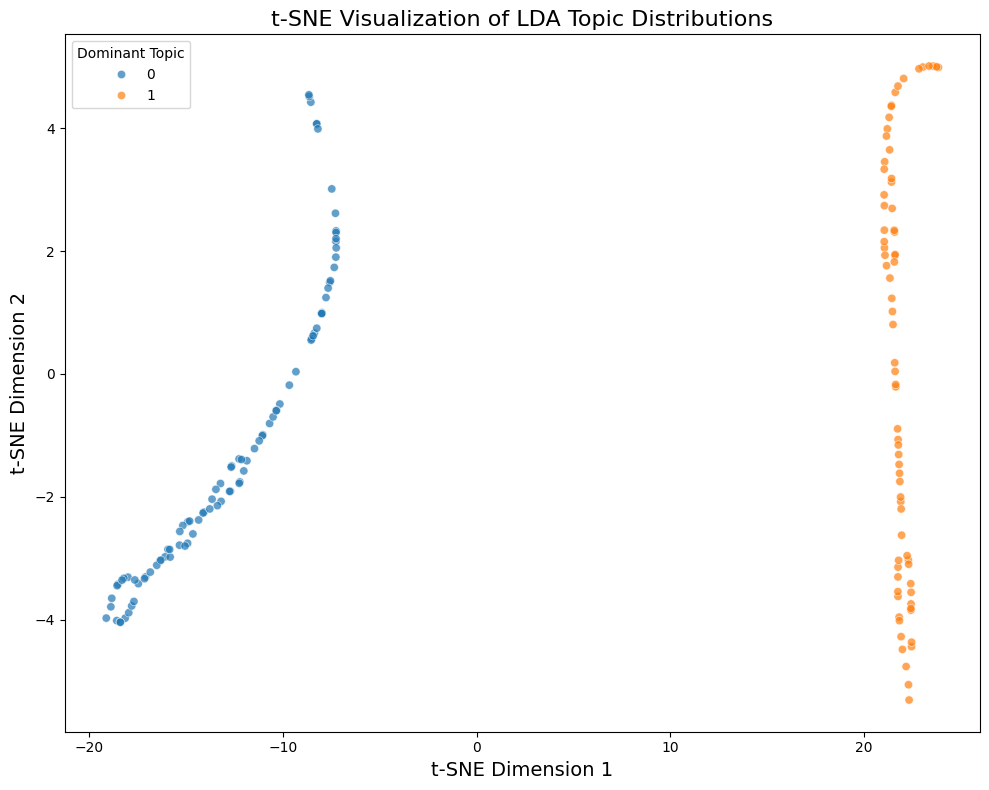

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.manifold import TSNE

# 1. Compute topic distributions for each document using your LDA model
# Each row corresponds to a document's topic distribution.
topic_distributions = best_lda.transform(count_data)

# 2. Apply t-SNE to reduce the topic distributions to 2D space
tsne_model = TSNE(n_components=2, random_state=42)
tsne_values = tsne_model.fit_transform(topic_distributions)

# 3. Create a DataFrame for the t-SNE results
tsne_df = pd.DataFrame(tsne_values, columns=['TSNE1', 'TSNE2'])
# Determine the dominant topic for each document (topic with highest probability)
tsne_df['dominant_topic'] = topic_distributions.argmax(axis=1)

# 4. Visualize the 2D representation using a scatter plot
plt.figure(figsize=(10, 8))
scatter = sns.scatterplot(
    x='TSNE1',
    y='TSNE2',
    hue='dominant_topic',
    palette='tab10',
    data=tsne_df,
    legend='full',
    alpha=0.7
)

plt.title('t-SNE Visualization of LDA Topic Distributions', fontsize=16)
plt.xlabel('t-SNE Dimension 1', fontsize=14)
plt.ylabel('t-SNE Dimension 2', fontsize=14)
plt.legend(title='Dominant Topic', loc='best')
plt.tight_layout()
plt.show()



LDA Topic Distribution per Document:
      Topic 0   Topic 1
0    0.023294  0.976706
1    0.988917  0.011083
2    0.979361  0.020639
3    0.994306  0.005694
4    0.987805  0.012195
..        ...       ...
161  0.988838  0.011162
162  0.015133  0.984867
163  0.978900  0.021100
164  0.976078  0.023922
165  0.970004  0.029996

[166 rows x 2 columns]


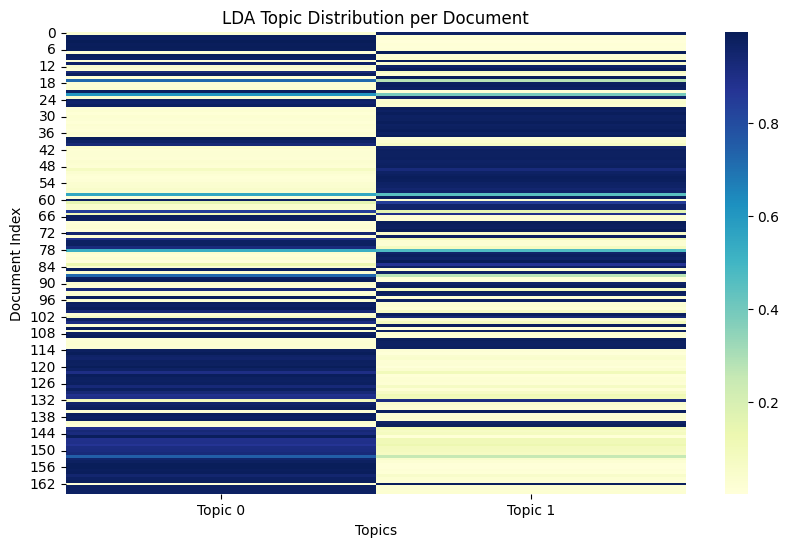

In [37]:
lda_topic_distribution = best_lda.transform(count_data)
df_lda_topics = pd.DataFrame(lda_topic_distribution, 
                             columns=[f"Topic {i}" for i in range(lda_topic_distribution.shape[1])])
print("\nLDA Topic Distribution per Document:")
print(df_lda_topics)

# Visualize LDA topic distributions as a heatmap:
plt.figure(figsize=(10, 6))
sns.heatmap(df_lda_topics, annot=False, cmap='YlGnBu')
plt.title('LDA Topic Distribution per Document')
plt.xlabel('Topics')
plt.ylabel('Document Index')
plt.show()


## NMF

In [31]:
nmf = NMF(random_state=42)

param_grid_nmf = {
    'n_components': [2, 3, 4, 5, 6]
}

nmf_search = GridSearchCV(nmf, param_grid=param_grid_nmf, cv=3, scoring='neg_mean_squared_error')
nmf_search.fit(tfidf_data)

best_nmf = nmf_search.best_estimator_
best_nmf_topics = nmf_search.best_params_['n_components']
print("Best NMF model's number of topics:", best_nmf_topics)


C:\Users\sthaa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\sthaa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_validation.py", line 947, in _score
    scores = scorer(estimator, X_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: _BaseScorer.__call__() missing 1 required positional argument: 'y_true'

  warnings.warn(
C:\Users\sthaa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_validation.py:960: UserWarning: Scoring failed. The score on this train-test par

Best NMF model's number of topics: 2


In [32]:
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

def display_nmf_topics(model, feature_names, no_top_words=10):
    for idx, topic in enumerate(model.components_):
        print(f"\nTopic {idx}:")
        top_indices = topic.argsort()[-no_top_words:]
        top_words = [feature_names[i] for i in top_indices]
        print(" ".join(top_words))

display_nmf_topics(best_nmf, tfidf_feature_names, no_top_words=7)



Topic 0:
weight value regularization feature random_forest data model

Topic 1:
use training_data text_classification ranking_algorithm answer gradient_boosting _answer


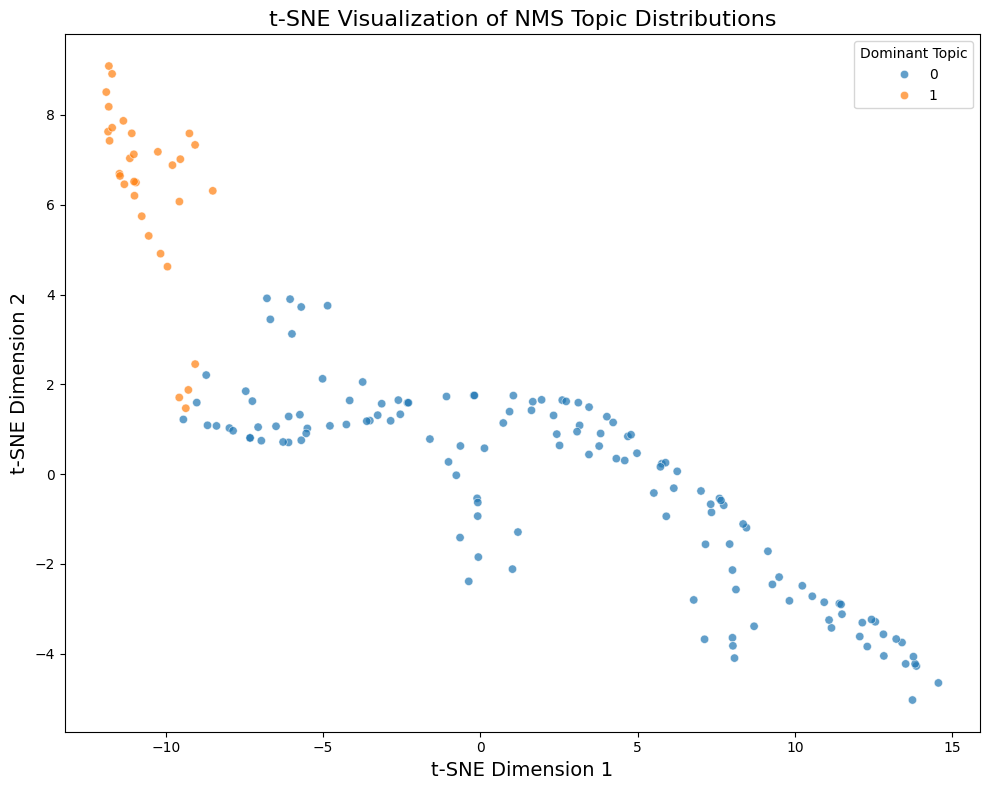

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.manifold import TSNE

# 1. Compute topic distributions for each document using your LDA model
# Each row corresponds to a document's topic distribution.
topic_distributions = best_nmf.transform(count_data)

# 2. Apply t-SNE to reduce the topic distributions to 2D space
tsne_model = TSNE(n_components=2, random_state=42)
tsne_values = tsne_model.fit_transform(topic_distributions)

# 3. Create a DataFrame for the t-SNE results
tsne_df = pd.DataFrame(tsne_values, columns=['TSNE1', 'TSNE2'])
# Determine the dominant topic for each document (topic with highest probability)
tsne_df['dominant_topic'] = topic_distributions.argmax(axis=1)

# 4. Visualize the 2D representation using a scatter plot
plt.figure(figsize=(10, 8))
scatter = sns.scatterplot(
    x='TSNE1',
    y='TSNE2',
    hue='dominant_topic',
    palette='tab10',
    data=tsne_df,
    legend='full',
    alpha=0.7
)

plt.title('t-SNE Visualization of NMS Topic Distributions', fontsize=16)
plt.xlabel('t-SNE Dimension 1', fontsize=14)
plt.ylabel('t-SNE Dimension 2', fontsize=14)
plt.legend(title='Dominant Topic', loc='best')
plt.tight_layout()
plt.show()



NMF Topic Distribution per Document:
      Topic 0   Topic 1
0    0.138914  0.043824
1    0.113798  0.000000
2    0.132858  0.003082
3    0.130794  0.000000
4    0.058877  0.013157
..        ...       ...
161  0.074624  0.000000
162  0.084268  0.000000
163  0.099254  0.000000
164  0.135332  0.000000
165  0.111491  0.087522

[166 rows x 2 columns]


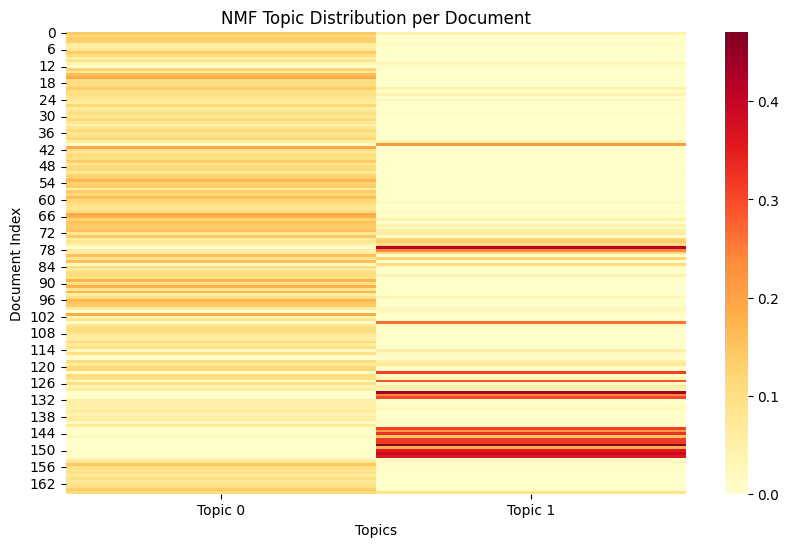

In [ ]:
# For NMF:
nmf_topic_distribution = best_nmf.transform(tfidf_data)
df_nmf_topics = pd.DataFrame(nmf_topic_distribution, 
                             columns=[f"Topic {i}" for i in range(nmf_topic_distribution.shape[1])])
print("\nNMF Topic Distribution per Document:")
print(df_nmf_topics)

plt.figure(figsize=(10, 6))  
sns.heatmap(df_nmf_topics, cmap='YlOrRd', annot=False)
plt.title("NMF Topic Distribution per Document")
plt.xlabel("Topics")
plt.ylabel("Document Index")
plt.show()